# Bayesian Optimisation

Univariate parameter sweeps (Notebook 4) treat each parameter in isolation, but market making parameters interact: a wider spread (high κ) amplifies both the benefit of a strong OFI filter and the cost of poor inventory management. This notebook addresses that limitation using Optuna to search the joint parameter space via Bayesian optimisation.

Two validation methodologies are compared: a simple chronological train/validation split as a baseline, and walk-forward cross-validation, which averages out-of-sample Sharpe across multiple rolling windows and is more robust to regime differences.

## 1. Setup & Data

10,000 trades are fetched from Coinbase Exchange and split chronologically: the first 7,000 form the training set and the remaining 3,000 are held out for validation. Preserving time order is essential as random splits would leak future price information into training.

In [14]:
import sys
sys.path.append('..')
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import numpy as np
import pandas as pd
import requests
from src.order_book import OrderBook
from src.market_maker import MarketMaker
from src.simulator import Simulator
from src.order_book import Side, Order

In [15]:
def get_btc_trades_extended(n_batches=5):
    url = "https://api.exchange.coinbase.com/products/BTC-USD/trades"
    all_trades = []

    params = {"limit": 1000}
    for _ in range(n_batches):
        response = requests.get(url, params=params)
        batch = response.json()
        if not batch:
            break
        all_trades.extend(batch)
        oldest_id = min(t["trade_id"] for t in batch)
        params = {"limit": 1000, "after": oldest_id}

    df = pd.DataFrame(all_trades)
    df["price"] = pd.to_numeric(df["price"])
    df["size"] = pd.to_numeric(df["size"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.drop_duplicates(subset="trade_id")
    df = df.sort_values("time").reset_index(drop=True)
    df = df.set_index("time")
    return df

In [16]:
def run_simulation(trades: pd.DataFrame, gamma=0.1, kappa=1.5, alpha=1.0, beta=1.0, ofi_threshold=0.8, mid_price_window=20):
    book = OrderBook()
    mm = MarketMaker(starting_wealth=100000, order_book=book, gamma=gamma, kappa=kappa, alpha=alpha, beta=beta)
    sim = Simulator(mm, book, trades, mid_price_window)
    sim.run(ofi_threshold)
    sim_results = sim.get_results()
    returns = sim_results['PnL'].diff().dropna()
    return returns.mean() / returns.std()

In [19]:
all_trades = get_btc_trades_extended(n_batches=10) 

train_trades = all_trades.iloc[:7000]   
val_trades = all_trades.iloc[7000:]

## 2. Initial Optimisation

The objective function maximises Sharpe ratio over the training window. Parameters and search ranges are informed by the univariate analysis in Notebook 4:

| Parameter | Search Range | Rationale |
|-----------|:-----------:|-----------|
| γ (gamma) | [0.1, 3.0] | Wider range now that σ estimation is improved via `mid_price_window` |
| κ (kappa) | [1.0, 20.0] | Previously identified as the dominant parameter |
| α (alpha) | [0.1, 3.0] | Dynamic spread multiplier; flat in isolation but may interact with γ |
| β (beta) | [0.1, 3.0] | Dynamic spread multiplier |
| OFI threshold | [0.63, 0.90] | Lower bound set above the identified cliff at ~0.60 |
| mid_price_window | [10, 100] | Lookback for σ estimation — the key unknown from prior analysis |

In [20]:
def objective(trial):
    gamma = trial.suggest_float('gamma', 0.1, 3.0)
    kappa = trial.suggest_float('kappa', 1.0, 20.0)
    alpha = trial.suggest_float('alpha', 0.1, 3.0)
    beta = trial.suggest_float('beta', 0.1, 3.0)
    ofi_threshold = trial.suggest_float('ofi_threshold', 0.63, 0.90)
    mid_price_window = trial.suggest_int('mid_price_window', 10, 100)
    
    return run_simulation(
        trades=train_trades,
        gamma=gamma,
        kappa=kappa,
        alpha=alpha,
        beta=beta,
        ofi_threshold=ofi_threshold,
        mid_price_window=mid_price_window
    )

In [21]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

In [22]:
print("Best parameters:")
print(study.best_params)
print(f"\nBest Sharpe: {study.best_value:.4f}")

Best parameters:
{'gamma': 1.873428390876355, 'kappa': 3.8311789803335246, 'alpha': 0.605891532449289, 'beta': 0.9739738105940651, 'ofi_threshold': 0.8293815542345921, 'mid_price_window': 73}

Best Sharpe: 0.2377


### Out-of-Sample Evaluation

The best parameters found on the training set are applied to the held-out validation window. A baseline run using default parameters is included for comparison to separate genuine optimzsation gains from the effect of market regime.

In [23]:
best = study.best_params
val_sharpe = run_simulation(
    val_trades,
    gamma=best['gamma'],
    kappa=best['kappa'],
    alpha=best['alpha'],
    beta=best['beta'],
    ofi_threshold=best['ofi_threshold'],
    mid_price_window=best['mid_price_window']
)
print(f"Validation Sharpe: {val_sharpe:.4f}")

Validation Sharpe: -0.1866


In [24]:
print(f"Train price change: {train_trades['price'].iloc[-1] - train_trades['price'].iloc[0]:.2f}")
print(f"Val price change: {val_trades['price'].iloc[-1] - val_trades['price'].iloc[0]:.2f}")
print(f"Train buy/sell ratio: {len(train_trades[train_trades['side']=='buy']) / len(train_trades):.2f}")
print(f"Val buy/sell ratio: {len(val_trades[val_trades['side']=='buy']) / len(val_trades):.2f}")

Train price change: 62.09
Val price change: -108.22
Train buy/sell ratio: 0.55
Val buy/sell ratio: 0.57


In [25]:
baseline_val_sharpe = run_simulation(
    val_trades,
    gamma=0.1,
    kappa=1.5,
    alpha=1.0,
    beta=1.0,
    ofi_threshold=0.8,
    mid_price_window=20
)
print(f"Baseline validation Sharpe: {baseline_val_sharpe:.4f}")

Baseline validation Sharpe: -0.1120


### Analysis

The optimized model achieved a training Sharpe of 0.2377 but a validation Sharpe of −0.1866. The regime diagnostics above explain why: the training window was bullish (+$62) while the validation window was sharply bearish (−$108). Critically, the **baseline model also performed negatively** on the same validation window (Sharpe: −0.1120), confirming this is a **regime mismatch problem, not overfitting**.

This motivates a more robust evaluation methodology. A single chronological split is vulnerable to the particular regime of the validation window.

---

## 3. Walk-Forward Validation

Walk-forward validation averages out-of-sample performance across multiple rolling windows, each covering different market conditions. Optimization runs independently on each training fold, and the resulting parameters are evaluated on the corresponding held-out validation fold. The data structure used here:

| Fold | Train Window | Validation Window |
|:----:|:------------:|:-----------------:|
| 1 | Trades 0 – 11,999 | Trades 12,000 – 13,999 |
| 2 | Trades 2,000 – 13,999 | Trades 14,000 – 15,999 |
| 3 | Trades 4,000 – 15,999 | Trades 16,000 – 17,999 |
| 4 | Trades 6,000 – 17,999 | Trades 18,000 – 19,999 |

In [27]:
def walk_forward_optimization(all_trades, n_trials=100, 
                               train_size=12000, val_size=2000, step_size=2000):
    
    folds = []
    start = 0
    fold_num = 1
    
    while start + train_size + val_size <= len(all_trades):
        train = all_trades.iloc[start:start + train_size]
        val = all_trades.iloc[start + train_size:start + train_size + val_size]
        
        print(f"\n=== Fold {fold_num} ===")
        print(f"Train: trades {start} to {start + train_size}")
        print(f"Val: trades {start + train_size} to {start + train_size + val_size}")
        print(f"Train price change: ${train['price'].iloc[-1] - train['price'].iloc[0]:.2f}")
        print(f"Val price change: ${val['price'].iloc[-1] - val['price'].iloc[0]:.2f}")
        def loop_objective(trial):
            gamma = trial.suggest_float('gamma', 0.1, 3.0)
            kappa = trial.suggest_float('kappa', 1.0, 20.0)
            alpha = trial.suggest_float('alpha', 0.1, 3.0)
            beta = trial.suggest_float('beta', 0.1, 3.0)
            ofi_threshold = trial.suggest_float('ofi_threshold', 0.63, 0.90)
            mid_price_window = trial.suggest_int('mid_price_window', 10, 100)
            return run_simulation(train, gamma=gamma, kappa=kappa, alpha=alpha,
                                beta=beta, ofi_threshold=ofi_threshold,
                                mid_price_window=mid_price_window)
        
        
        walk_study = optuna.create_study(direction='maximize')
        walk_study.optimize(loop_objective, n_trials=n_trials)
        
        walk_best_params = walk_study.best_params
        walk_best_value = walk_study.best_value
        
        walk_val_sharpe = run_simulation(val, **walk_best_params)
        
        folds.append({
            'fold': fold_num,
            'best_params': walk_best_params,
            'train_sharpe': walk_best_value,
            'val_sharpe': walk_val_sharpe,
            'train_price_change': train['price'].iloc[-1] - train['price'].iloc[0],
            'val_price_change': val['price'].iloc[-1] - val['price'].iloc[0]
        })
        print(f"Train Sharpe: {walk_best_value:.4f}")
        print(f"Val Sharpe: {walk_val_sharpe:.4f}")

        start += step_size
        fold_num += 1
    
    return folds

In [28]:
all_trades = get_btc_trades_extended(n_batches=20)
walk_forward_optimization(all_trades=all_trades)


=== Fold 1 ===
Train: trades 0 to 12000
Val: trades 12000 to 14000
Train price change: $-58.43
Val price change: $28.21
Train Sharpe: 0.1406
Val Sharpe: 0.1158

=== Fold 2 ===
Train: trades 2000 to 14000
Val: trades 14000 to 16000
Train price change: $-71.21
Val price change: $-106.31
Train Sharpe: 0.1238
Val Sharpe: 0.2012

=== Fold 3 ===
Train: trades 4000 to 16000
Val: trades 16000 to 18000
Train price change: $-205.35
Val price change: $-47.57
Train Sharpe: 0.1543
Val Sharpe: 0.1058

=== Fold 4 ===
Train: trades 6000 to 18000
Val: trades 18000 to 20000
Train price change: $-201.86
Val price change: $20.55
Train Sharpe: 0.1885
Val Sharpe: 0.2044


[{'fold': 1,
  'best_params': {'gamma': 0.9988862338596073,
   'kappa': 16.21503931864118,
   'alpha': 2.285330860734013,
   'beta': 2.1602431422860273,
   'ofi_threshold': 0.6644377994804553,
   'mid_price_window': 95},
  'train_sharpe': 0.1405715461076916,
  'val_sharpe': np.float64(0.11583371724169202),
  'train_price_change': np.float64(-58.429999999993015),
  'val_price_change': np.float64(28.20999999999185)},
 {'fold': 2,
  'best_params': {'gamma': 1.5834116547892543,
   'kappa': 1.0636956563509603,
   'alpha': 0.39149062464250495,
   'beta': 0.736506212213064,
   'ofi_threshold': 0.8765465574371855,
   'mid_price_window': 97},
  'train_sharpe': 0.12383873296470134,
  'val_sharpe': np.float64(0.20123991960988355),
  'train_price_change': np.float64(-71.2100000000064),
  'val_price_change': np.float64(-106.30999999999767)},
 {'fold': 3,
  'best_params': {'gamma': 1.6135888613123075,
   'kappa': 19.976062349090377,
   'alpha': 0.11659508040178873,
   'beta': 2.53001222755105,
   'o

### Results

Walk-forward validation produced positive out-of-sample Sharpe across all four folds, with a **mean validation Sharpe of 0.157**, a substantial improvement over the negative-Sharpe baseline runs in earlier notebooks.

**Key findings:**

- **No overfitting detected.** In two of four folds, validation Sharpe exceeded training Sharpe, indicating the optimized parameters generalize rather than fitting noise.
- **Parameters vary significantly across folds**, confirming regime sensitivity:
  - κ ranges from 1.06 to 19.98
  - α ranges from 0.12 to 2.29
  - OFI threshold ranges from 0.64 to 0.88

  This variance supports the case for regime-adaptive parameter selection as future work.
- **`mid_price_window` consistently converges to 95–100 across all folds.** This is the most robust finding from the entire optimization. Smoother σ estimation is beneficial regardless of market conditions, making it the single most reliable insight from this project.
- **Regime does not predict the performance gap.** Training windows were predominantly bearish, yet validation Sharpe is positive and variable across all folds. The strategy is regime-*sensitive* but not regime-*dependent*.

In [30]:
results = [{'fold': 1,
  'best_params': {'gamma': 0.9988862338596073,
   'kappa': 16.21503931864118,
   'alpha': 2.285330860734013,
   'beta': 2.1602431422860273,
   'ofi_threshold': 0.6644377994804553,
   'mid_price_window': 95},
  'train_sharpe': 0.1405715461076916,
  'val_sharpe': np.float64(0.11583371724169202),
  'train_price_change': np.float64(-58.429999999993015),
  'val_price_change': np.float64(28.20999999999185)},
 {'fold': 2,
  'best_params': {'gamma': 1.5834116547892543,
   'kappa': 1.0636956563509603,
   'alpha': 0.39149062464250495,
   'beta': 0.736506212213064,
   'ofi_threshold': 0.8765465574371855,
   'mid_price_window': 97},
  'train_sharpe': 0.12383873296470134,
  'val_sharpe': np.float64(0.20123991960988355),
  'train_price_change': np.float64(-71.2100000000064),
  'val_price_change': np.float64(-106.30999999999767)},
 {'fold': 3,
  'best_params': {'gamma': 1.6135888613123075,
   'kappa': 19.976062349090377,
   'alpha': 0.11659508040178873,
   'beta': 2.53001222755105,
   'ofi_threshold': 0.6482191693941416,
   'mid_price_window': 99},
  'train_sharpe': 0.15431489304941207,
  'val_sharpe': np.float64(0.10579216488924001),
  'train_price_change': np.float64(-205.35000000000582),
  'val_price_change': np.float64(-47.56999999999243)},
 {'fold': 4,
  'best_params': {'gamma': 1.8313341338226785,
   'kappa': 1.9425704664459886,
   'alpha': 0.9964679543499504,
   'beta': 2.722682921138399,
   'ofi_threshold': 0.6374054657019419,
   'mid_price_window': 100},
  'train_sharpe': 0.18850901513461346,
  'val_sharpe': np.float64(0.2044372250478795),
  'train_price_change': np.float64(-201.86000000000058),
  'val_price_change': np.float64(20.55000000000291)}]

In [31]:
folds_df = pd.DataFrame([{
    'fold': f['fold'],
    'train_sharpe': f['train_sharpe'],
    'val_sharpe': f['val_sharpe'],
    'train_price_change': f['train_price_change'],
    'val_price_change': f['val_price_change'],
    **f['best_params']
    } for f in results])

print(folds_df.to_string())
print(f"\nMean Train Sharpe: {folds_df['train_sharpe'].mean():.4f}")
print(f"Mean Val Sharpe: {folds_df['val_sharpe'].mean():.4f}")
print(f"Val Sharpe Std: {folds_df['val_sharpe'].std():.4f}")

   fold  train_sharpe  val_sharpe  train_price_change  val_price_change     gamma      kappa     alpha      beta  ofi_threshold  mid_price_window
0     1      0.140572    0.115834              -58.43             28.21  0.998886  16.215039  2.285331  2.160243       0.664438                95
1     2      0.123839    0.201240              -71.21           -106.31  1.583412   1.063696  0.391491  0.736506       0.876547                97
2     3      0.154315    0.105792             -205.35            -47.57  1.613589  19.976062  0.116595  2.530012       0.648219                99
3     4      0.188509    0.204437             -201.86             20.55  1.831334   1.942570  0.996468  2.722683       0.637405               100

Mean Train Sharpe: 0.1518
Mean Val Sharpe: 0.1568
Val Sharpe Std: 0.0533


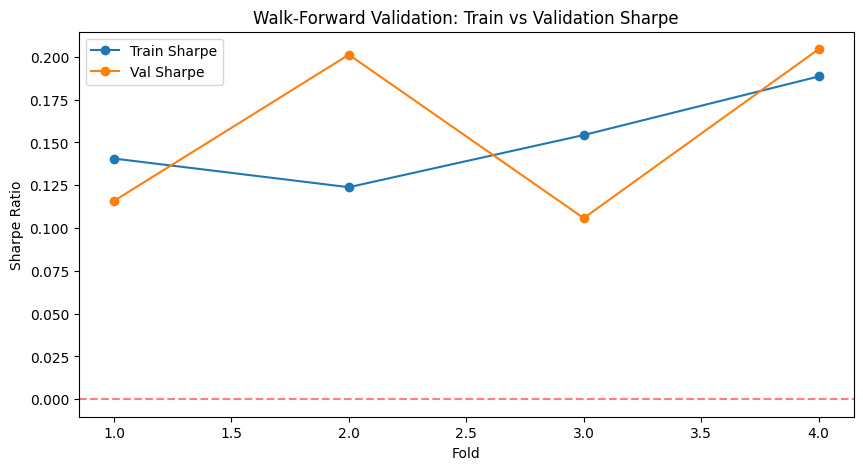

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(folds_df['fold'], folds_df['train_sharpe'], marker='o', label='Train Sharpe')
plt.plot(folds_df['fold'], folds_df['val_sharpe'], marker='o', label='Val Sharpe')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Fold')
plt.ylabel('Sharpe Ratio')
plt.title('Walk-Forward Validation: Train vs Validation Sharpe')
plt.legend()
plt.show()

## 4. Conclusions

Walk-forward validation demonstrates that Bayesian optimization produces reliable parameters. Positive out-of-sample Sharpe in every fold, with a mean of 0.157, represents a meaningful step forward from the negative or near-zero performance in earlier notebooks.

**Findings:**

1. **Smooth σ estimation is the most reliable lever.** `mid_price_window` converging to 95–100 across all folds is the strongest signal from the entire project. Fixing the σ unit mismatch (expressing sigma in dollar terms rather than proportional returns) and extending the lookback window will have the largest impact on performance. A smoother sigma impacts the strategy the most, and it's evident that we found that sigma with a high degree of certainty.

2. Walk forward validation is using a sliding window across all of the data for training data and valuation data. It respects the order and timing of the data. I used this method of validation since market data isn't validated by simply splitting the data into training and valuation data. **Market data is non-stationary** since the underlying distribution shifts over time making random train/val splits unreliable.

3. **Regime-adaptive parameters are the natural next step.** The wide variance in κ and OFI threshold across folds suggests that a regime classifier, such as a hidden Markov model, could significantly improve out-of-sample stability by selecting parameter sets conditioned on the current market state.